# Análise de Preços de Casas — Ames Housing Dataset

Este notebook segue as etapas: (1) Análise Exploratória, (2) Feature Engineering,
(3) Aprendizagem Supervisionada (Regressão e Classificação), (4) Aprendizagem
Não Supervisionada (Clusterização, PCA, Regras de Associação, Outliers) e
(5) Comparação de métricas e conclusões.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 1. Análise Exploratória de Dados (EDA)

In [52]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'train: {train.shape} | test: {test.shape}')
train.head()

train: (1460, 81) | test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [53]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [54]:
num_cols_count = train.select_dtypes(include=np.number).shape[1]
cat_cols_count = train.shape[1] - num_cols_count
print('Variáveis numéricas:', num_cols_count)
print('Variáveis categóricas:', cat_cols_count)
train.describe().T.head(10)

Variáveis numéricas: 38
Variáveis categóricas: 43


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


              missing   pct
PoolQC           1453  99.5
MiscFeature      1406  96.3
Alley            1369  93.8
Fence            1179  80.8
MasVnrType        872  59.7
FireplaceQu       690  47.3
LotFrontage       259  17.7
GarageType         81   5.5
GarageYrBlt        81   5.5
GarageFinish       81   5.5
GarageQual         81   5.5
GarageCond         81   5.5
BsmtExposure       38   2.6
BsmtFinType2       38   2.6
BsmtQual           37   2.5
BsmtCond           37   2.5
BsmtFinType1       37   2.5
MasVnrArea          8   0.5
Electrical          1   0.1


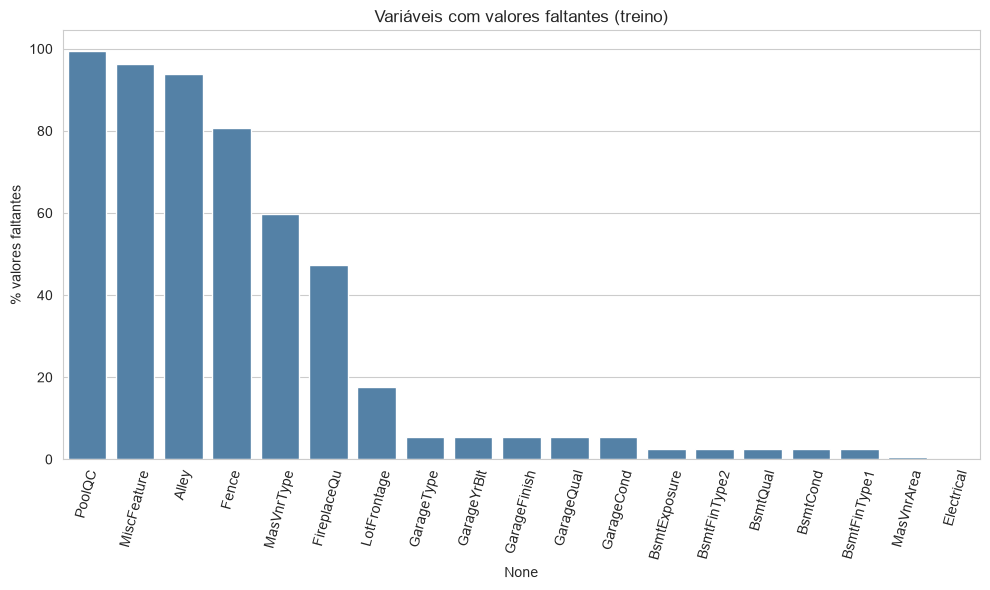

In [55]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=missing_df.index, y=missing_df['pct'], ax=ax, color='steelblue')
ax.set_ylabel('% valores faltantes')
ax.set_title('Variáveis com valores faltantes (treino)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

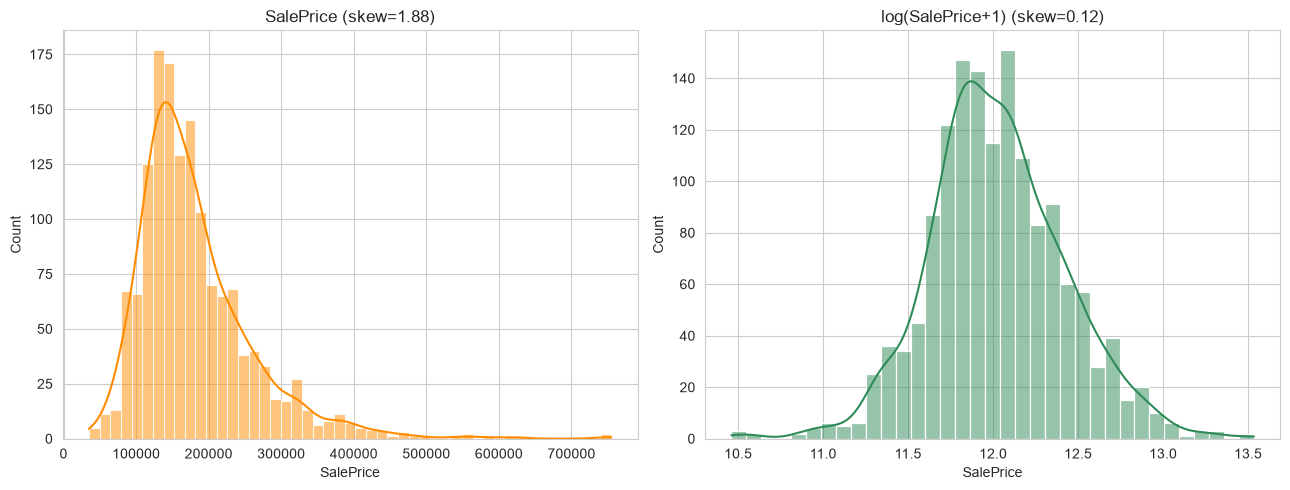

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='darkorange')
axes[0].set_title(f"SalePrice (skew={train['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"log(SalePrice+1) (skew={np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.show()

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


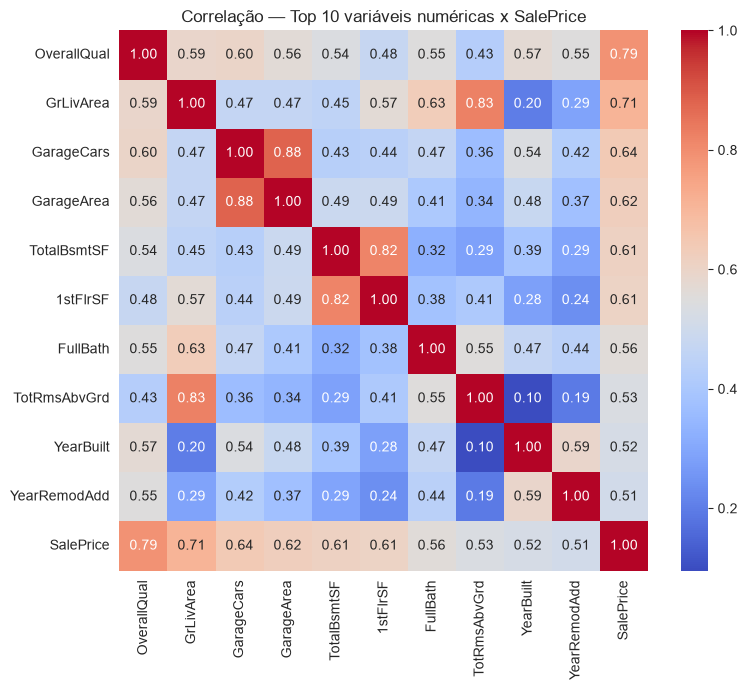

In [57]:
num_cols = train.select_dtypes(include=np.number).columns
corr = train[num_cols].corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(11))

top_feats = corr.index[1:11]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(train[list(top_feats) + ['SalePrice']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax)
ax.set_title('Correlação — Top 10 variáveis numéricas x SalePrice')
plt.tight_layout()
plt.show()

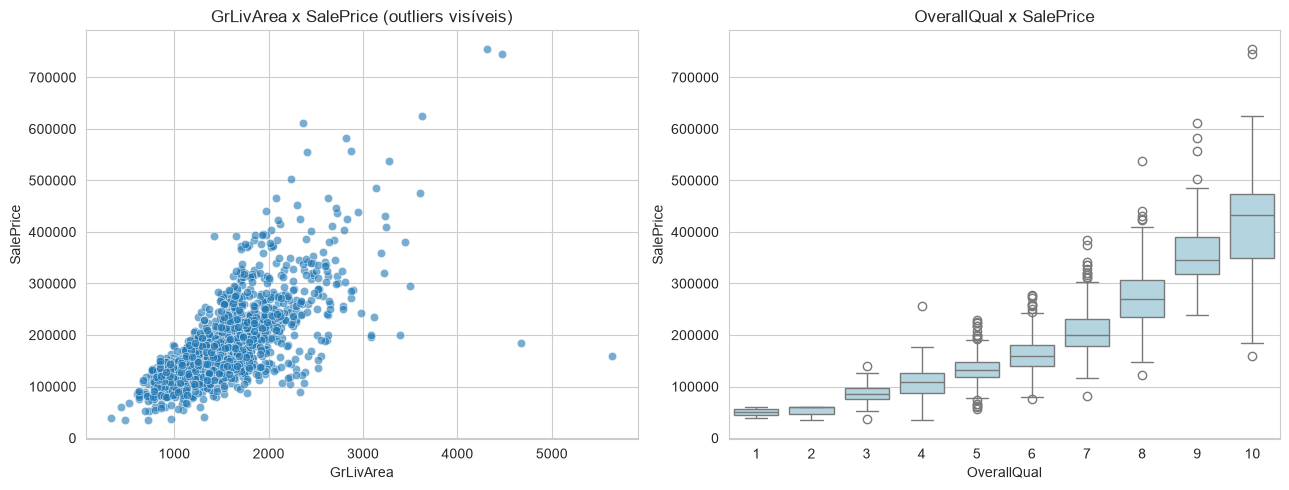

Outliers claros (GrLivArea>4000 e preço baixo): [523, 1298]


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=axes[0], alpha=0.6)
axes[0].set_title('GrLivArea x SalePrice (outliers visíveis)')
sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=axes[1], color='lightblue')
axes[1].set_title('OverallQual x SalePrice')
plt.tight_layout()
plt.show()

outliers_idx = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print('Outliers claros (GrLivArea>4000 e preço baixo):', list(outliers_idx))

## 2. Feature Engineering

In [59]:
train_ids = train['Id']
test_ids = test['Id']
y_full = train['SalePrice'].copy()

df = pd.concat([train.drop(columns=['SalePrice']), test], axis=0, ignore_index=True)
print('Shape combinado:', df.shape)

na_means_none = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                  'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
                  'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
                  'MiscFeature']
for col in na_means_none:
    df[col] = df[col].fillna('None')

Shape combinado: (2919, 80)


In [60]:
zero_fill = ['MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in zero_fill:
    df[col] = df[col].fillna(0)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda s: s.fillna(s.median()))

remaining_na = df.columns[df.isna().any()].tolist()
print('Restantes com NA (preenchidos com a moda):', remaining_na)
for col in remaining_na:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Total de NAs restantes:', df.isna().sum().sum())

Restantes com NA (preenchidos com a moda): ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'Functional', 'SaleType']
Total de NAs restantes: 0


In [61]:
df_train_part = df.iloc[:len(train)].copy()
df_train_part['SalePrice'] = y_full.values
df_train_part = df_train_part.drop(index=outliers_idx)
y_full = df_train_part['SalePrice']
df = pd.concat([df_train_part.drop(columns=['SalePrice']), df.iloc[len(train):]], axis=0, ignore_index=True)
n_train = len(df_train_part)
print('Novo shape treino (sem outliers):', n_train, '| teste:', len(df) - n_train)

Novo shape treino (sem outliers): 1458 | teste: 1459


In [62]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                    df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                       df['3SsnPorch'] + df['ScreenPorch'])
print('Novas features criadas: TotalSF, TotalBath, HouseAge, RemodAge, IsRemodeled, HasPool, HasGarage, HasFireplace, TotalPorchSF')

Novas features criadas: TotalSF, TotalBath, HouseAge, RemodAge, IsRemodeled, HasPool, HasGarage, HasFireplace, TotalPorchSF


In [63]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in ordinal_cols:
    df[col] = df[col].map(qual_map)

bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

In [64]:
# One-hot encoding para as variáveis nominais restantes
nominal_cols = [c for c in df.columns if c not in df.select_dtypes(include=np.number).columns]
print(f'{len(nominal_cols)} variáveis nominais para one-hot encoding')
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print('Shape após one-hot encoding:', df_encoded.shape)

30 variáveis nominais para one-hot encoding
Shape após one-hot encoding: (2917, 225)


In [65]:
# Trata a assimetria (skew) das variáveis numéricas mais distorcidas com log1p
numeric_feats = df_encoded.select_dtypes(include=np.number).columns
skewed = df_encoded[numeric_feats].apply(lambda s: stats.skew(s)).sort_values(ascending=False)
high_skew = skewed[abs(skewed) > 0.75].index
high_skew = [c for c in high_skew if c != 'Id']
for col in high_skew:
    df_encoded[col] = np.log1p(df_encoded[col] - df_encoded[col].min() + 1
                                if df_encoded[col].min() < 0 else df_encoded[col])
print(f'{len(high_skew)} features com skew>0.75 transformadas com log1p')

# Target também é transformado (estabiliza variância, comum nesse dataset)
y_log = np.log1p(y_full)

34 features com skew>0.75 transformadas com log1p


In [66]:
# Separa novamente treino e teste já processados
X = df_encoded.iloc[:n_train].drop(columns=['Id']).reset_index(drop=True)
X_test_final = df_encoded.iloc[n_train:].drop(columns=['Id']).reset_index(drop=True)
y = y_log.reset_index(drop=True)
y_original = y_full.reset_index(drop=True)
print('X:', X.shape, '| y:', y.shape, '| X_test_final:', X_test_final.shape)

X: (1458, 224) | y: (1458,) | X_test_final: (1459, 224)


## 3. Aprendizagem Supervisionada — Regressão
Objetivo: prever o valor numérico de `SalePrice` (em escala log).

In [67]:
X_train, X_val, y_train, y_val, y_orig_train, y_orig_val = train_test_split(
    X, y, y_original, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

# Modelo 1: Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)
pred_lin_log = lin_reg.predict(X_val_sc)
pred_lin = np.expm1(pred_lin_log)

# Modelo 2: Random Forest Regressor (comparação)
rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
pred_rf_log = rf_reg.predict(X_val)
pred_rf = np.expm1(pred_rf_log)

def reg_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{name:18s} | RMSE: R$ {rmse:,.0f} | MAE: R$ {mae:,.0f} | R²: {r2:.4f}')
    return {'modelo': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

reg_results = []
reg_results.append(reg_metrics(y_orig_val, pred_lin, 'Regressão Linear'))
reg_results.append(reg_metrics(y_orig_val, pred_rf, 'Random Forest Reg.'))

Regressão Linear   | RMSE: R$ 22,818 | MAE: R$ 15,475 | R²: 0.9057
Random Forest Reg. | RMSE: R$ 23,520 | MAE: R$ 16,413 | R²: 0.8999


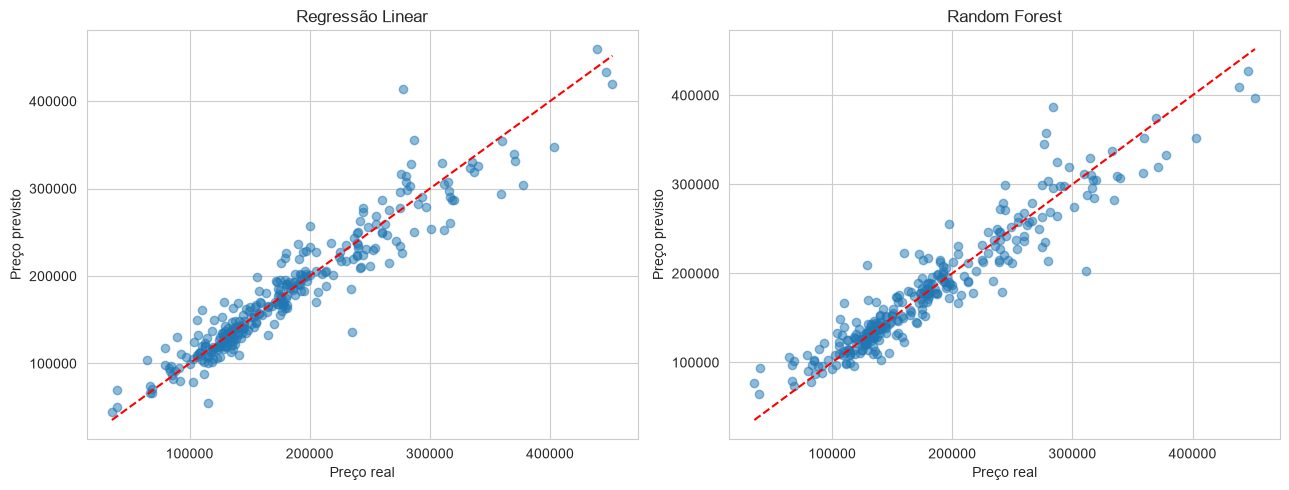

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(axes, [pred_lin, pred_rf], ['Regressão Linear', 'Random Forest']):
    ax.scatter(y_orig_val, pred, alpha=0.5)
    lims = [y_orig_val.min(), y_orig_val.max()]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Preço real')
    ax.set_ylabel('Preço previsto')
    ax.set_title(title)
plt.tight_layout()
plt.show()

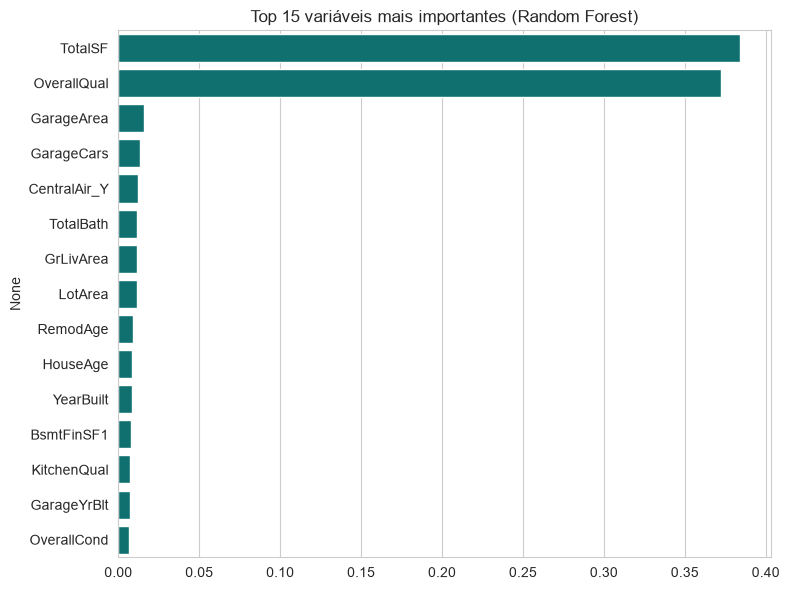

In [69]:
# Importância das variáveis segundo o Random Forest
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color='teal')
ax.set_title('Top 15 variáveis mais importantes (Random Forest)')
plt.tight_layout()
plt.show()

## 4. Aprendizagem Supervisionada — Classificação
A variável `SalePrice` é convertida em binária (Alta/Baixa, separada pela mediana)
e usada para prever a faixa de preço da casa.

In [70]:
median_price = y_orig_train.median()

median_full = y_original.median()
y_class_full = (y_original > median_full).astype(int)
print('Mediana do preço (treino completo):', f'R$ {median_full:,.0f}')
print('Distribuição das classes:', y_class_full.value_counts().to_dict())

Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X, y_class_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class_full)
Xc_train_sc = scaler.fit_transform(Xc_train)
Xc_val_sc = scaler.transform(Xc_val)

Mediana do preço (treino completo): R$ 163,000
Distribuição das classes: {0: 731, 1: 727}


In [71]:
log_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_clf.fit(Xc_train_sc, yc_train)
pred_log = log_clf.predict(Xc_val_sc)
proba_log = log_clf.predict_proba(Xc_val_sc)[:, 1]

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(Xc_train, yc_train)
pred_rfc = rf_clf.predict(Xc_val)
proba_rfc = rf_clf.predict_proba(Xc_val)[:, 1]

def clf_metrics(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f'{name:18s} | Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}')
    return {'modelo': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

clf_results = []
clf_results.append(clf_metrics(yc_val, pred_log, proba_log, 'Regressão Logística'))
clf_results.append(clf_metrics(yc_val, pred_rfc, proba_rfc, 'Random Forest Clf.'))

Regressão Logística | Acc: 0.901 | Prec: 0.903 | Rec: 0.897 | F1: 0.900 | AUC: 0.971
Random Forest Clf. | Acc: 0.911 | Prec: 0.941 | Rec: 0.877 | F1: 0.908 | AUC: 0.982


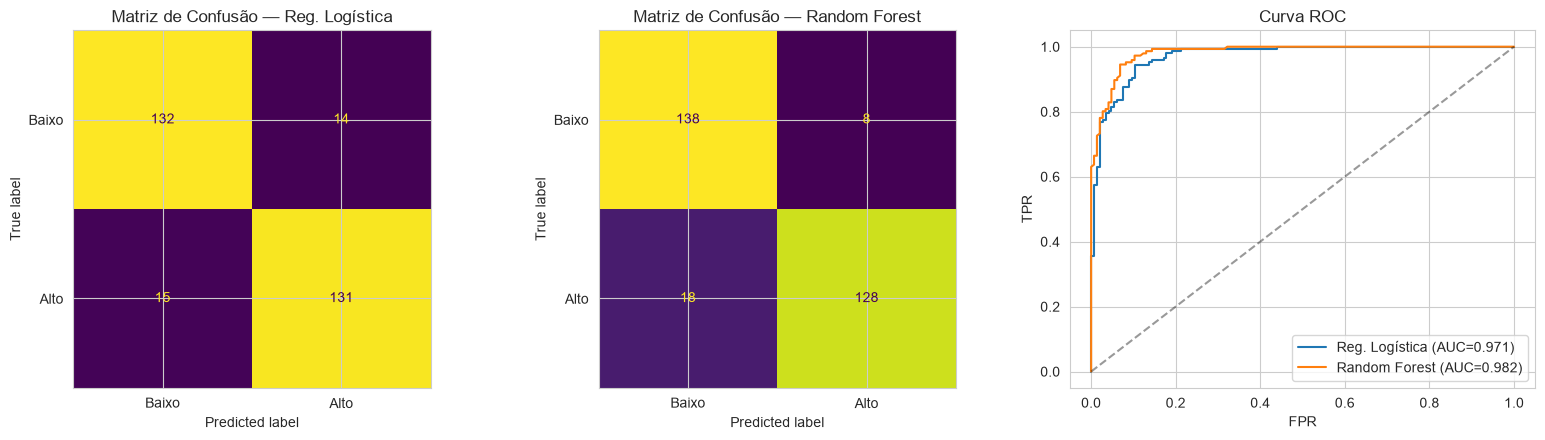

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yc_val, pred_log), display_labels=['Baixo', 'Alto']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusão — Reg. Logística')
ConfusionMatrixDisplay(confusion_matrix(yc_val, pred_rfc), display_labels=['Baixo', 'Alto']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de Confusão — Random Forest')

for proba, label in [(proba_log, 'Reg. Logística'), (proba_rfc, 'Random Forest')]:
    fpr, tpr, _ = roc_curve(yc_val, proba)
    axes[2].plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(yc_val, proba):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].set_title('Curva ROC')
axes[2].legend()
plt.tight_layout()
plt.show()

## 5. Aprendizagem Não Supervisionada — Clusterização (K-Means)
Objetivo: agrupar casas com características semelhantes, sem usar `SalePrice`.

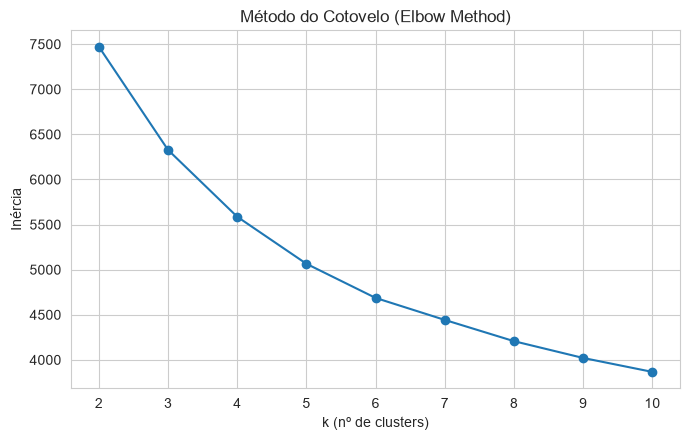

In [73]:
cluster_feats = ['OverallQual', 'GrLivArea', 'TotalSF', 'TotalBath', 'GarageCars',
                  'YearBuilt', 'TotRmsAbvGrd', 'LotArea']
# Usamos a escala original (antes do log1p) para manter a interpretação direta dos clusters
X_cluster = df.iloc[:n_train][cluster_feats].reset_index(drop=True)
# LotArea é fortemente assimétrico (poucos lotes enormes); aplicamos log1p só para o
# cálculo de distância do K-Means, evitando que esses poucos pontos dominem os clusters
X_cluster_for_algo = X_cluster.copy()
X_cluster_for_algo['LotArea'] = np.log1p(X_cluster_for_algo['LotArea'])
X_cluster_sc = StandardScaler().fit_transform(X_cluster_for_algo)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(K_range), inertias, 'o-')
ax.set_xlabel('k (nº de clusters)'); ax.set_ylabel('Inércia')
ax.set_title('Método do Cotovelo (Elbow Method)')
plt.tight_layout()
plt.show()

         OverallQual  GrLivArea  TotalSF  TotalBath  GarageCars  YearBuilt  \
Cluster                                                                      
0                6.9     1561.7   2707.4        2.6         2.1     1996.8   
1                5.0     1055.9   1877.8        1.6         1.2     1954.5   
2                8.0     2326.8   3845.3        3.1         2.7     1992.4   
3                5.6     1766.2   2757.4        2.1         1.6     1943.9   

         TotRmsAbvGrd  LotArea  SalePrice  
Cluster                                    
0                 6.4   9351.2   203108.5  
1                 5.3   8222.4   121013.5  
2                 8.7  17555.9   323243.2  
3                 7.6  12001.6   162054.0  

Contagem por cluster:
0    475
1    535
2    186
3    262
Name: count, dtype: int64


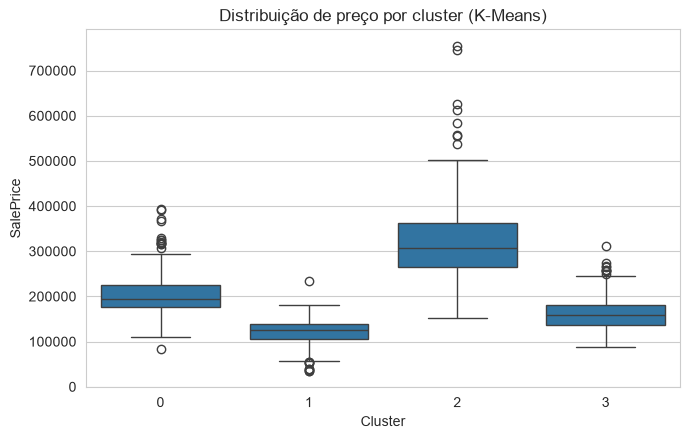

In [74]:
K_CHOSEN = 4
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_cluster_sc)

cluster_profile = X_cluster.copy()
cluster_profile['Cluster'] = clusters
cluster_profile['SalePrice'] = y_original.values
print(cluster_profile.groupby('Cluster').mean().round(1))
print()
print('Contagem por cluster:')
print(pd.Series(clusters).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x=clusters, y=y_original.values, ax=ax)
ax.set_xlabel('Cluster'); ax.set_ylabel('SalePrice')
ax.set_title('Distribuição de preço por cluster (K-Means)')
plt.tight_layout()
plt.show()

## 6. Aprendizagem Não Supervisionada — Redução de Dimensionalidade (PCA)

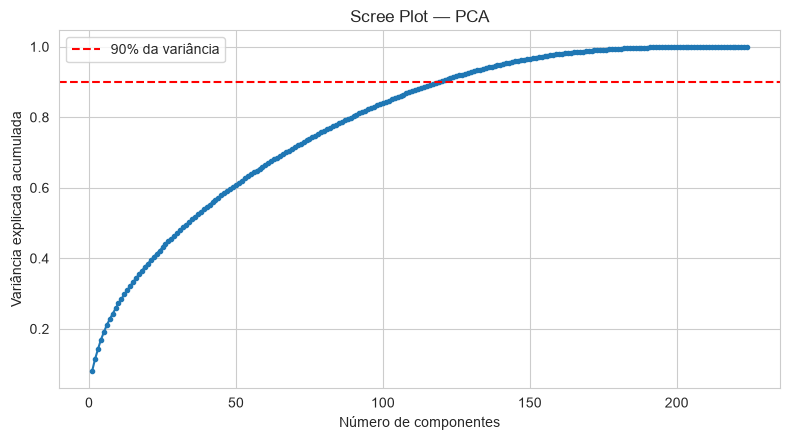

Componentes necessários para explicar 90% da variância: 119


In [75]:
X_all_sc = StandardScaler().fit_transform(X)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_all_sc)
explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(explained)+1), explained, marker='.')
ax.axhline(0.9, color='r', linestyle='--', label='90% da variância')
ax.set_xlabel('Número de componentes'); ax.set_ylabel('Variância explicada acumulada')
ax.set_title('Scree Plot — PCA')
ax.legend()
plt.tight_layout()
plt.show()

n_comp_90 = np.argmax(explained >= 0.9) + 1
print(f'Componentes necessários para explicar 90% da variância: {n_comp_90}')

Variância explicada pelas 2 primeiras componentes: 11.34%


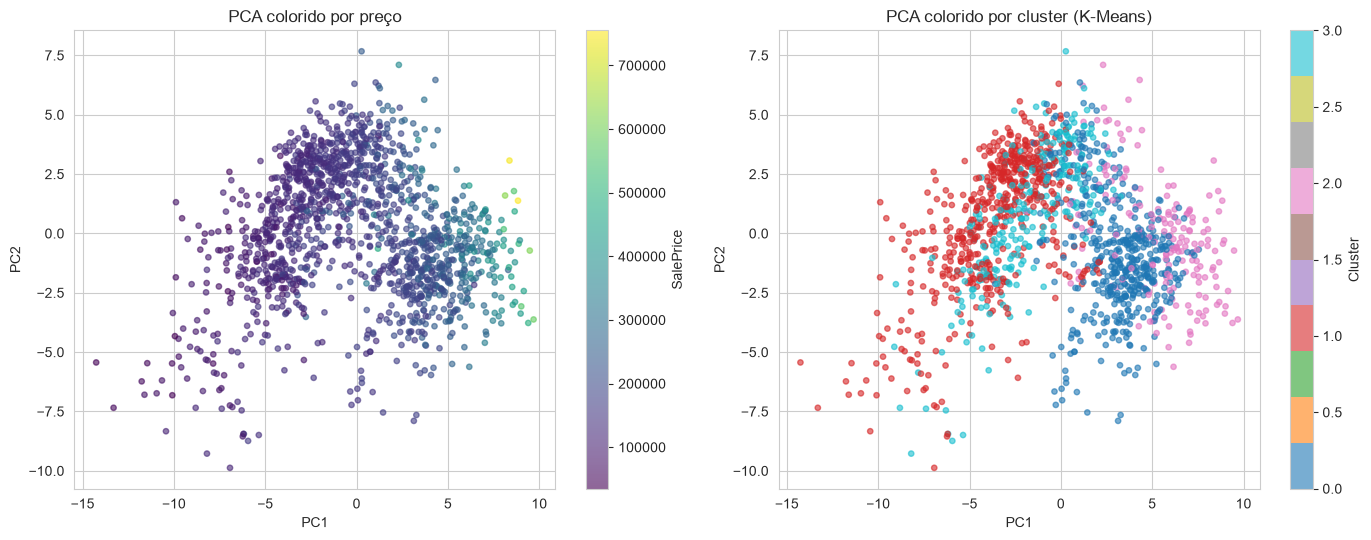

In [76]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_all_sc)
print(f'Variância explicada pelas 2 primeiras componentes: {pca2.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_original, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(sc1, ax=axes[0], label='SalePrice')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].set_title('PCA colorido por preço')

sc2 = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].set_title('PCA colorido por cluster (K-Means)')
plt.tight_layout()
plt.show()

## 7. Aprendizagem Não Supervisionada — Análise de Associação (Apriori)
Como o ambiente não possui a biblioteca `mlxtend`, implementamos uma versão
simplificada do algoritmo **Apriori** (geração de itemsets frequentes por nível,
com poda) para encontrar associações entre características das casas.

In [77]:
# Discretiza variáveis-chave em categorias ("itens") para formar transações
assoc_df = pd.DataFrame({
    'Qualidade': pd.cut(df.iloc[:n_train]['OverallQual'], bins=[0, 4, 6, 10],
                         labels=['Qualidade_Baixa', 'Qualidade_Media', 'Qualidade_Alta']),
    'Tamanho': pd.qcut(df.iloc[:n_train]['GrLivArea'], q=3,
                        labels=['Area_Pequena', 'Area_Media', 'Area_Grande']),
    'Idade': pd.cut(df.iloc[:n_train]['HouseAge'], bins=[-1, 10, 30, 200],
                     labels=['Casa_Nova', 'Casa_Media', 'Casa_Antiga']),
    'Garagem': np.where(df.iloc[:n_train]['GarageCars'] >= 2, 'Garagem_2+', 'Garagem_0-1'),
    'Preco': pd.qcut(y_original, q=3, labels=['Preco_Baixo', 'Preco_Medio', 'Preco_Alto']),
}).reset_index(drop=True)

transactions = assoc_df.apply(lambda row: set(row.astype(str)), axis=1).tolist()
print('Exemplo de transação:', transactions[0])
print('Total de transações:', len(transactions))

Exemplo de transação: {'Garagem_2+', 'Preco_Alto', 'Area_Grande', 'Casa_Nova', 'Qualidade_Alta'}
Total de transações: 1458


In [78]:
def get_support(itemset, transactions):
    count = sum(1 for t in transactions if itemset.issubset(t))
    return count / len(transactions)

def apriori_manual(transactions, min_support=0.05, max_len=3):
    """Implementação simplificada do algoritmo Apriori (geração por nível + poda)."""
    items = sorted(set().union(*transactions))
    # Nível 1
    L = {frozenset([item]): get_support(frozenset([item]), transactions) for item in items}
    L = {k: v for k, v in L.items() if v >= min_support}
    all_frequent = dict(L)
    k = 2
    while L and k <= max_len:
        candidates = set()
        prev_items = [frozenset(s) for s in L.keys()]
        for a, b in combinations(prev_items, 2):
            cand = a | b
            if len(cand) == k:
                candidates.add(cand)
        L_new = {}
        for cand in candidates:
            sup = get_support(cand, transactions)
            if sup >= min_support:
                L_new[cand] = sup
        all_frequent.update(L_new)
        L = L_new
        k += 1
    return all_frequent

frequent_itemsets = apriori_manual(transactions, min_support=0.05, max_len=3)
print(f'{len(frequent_itemsets)} itemsets frequentes encontrados (suporte mínimo 5%)')

145 itemsets frequentes encontrados (suporte mínimo 5%)


In [79]:
def generate_rules(frequent_itemsets, transactions, min_confidence=0.6):
    rules = []
    for itemset, sup_itemset in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for antecedent in combinations(itemset, i):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                sup_ant = get_support(antecedent, transactions)
                if sup_ant == 0:
                    continue
                confidence = sup_itemset / sup_ant
                sup_cons = get_support(consequent, transactions)
                lift = confidence / sup_cons if sup_cons > 0 else 0
                if confidence >= min_confidence:
                    rules.append({
                        'antecedente': ', '.join(antecedent),
                        'consequente': ', '.join(consequent),
                        'suporte': round(sup_itemset, 3),
                        'confianca': round(confidence, 3),
                        'lift': round(lift, 3),
                    })
    return pd.DataFrame(rules).sort_values('lift', ascending=False)

rules_df = generate_rules(frequent_itemsets, transactions, min_confidence=0.6)
print(rules_df.head(15).to_string(index=False))

                  antecedente               consequente  suporte  confianca  lift
              Qualidade_Baixa Preco_Baixo, Area_Pequena    0.069      0.716 3.108
              Qualidade_Baixa  Preco_Baixo, Casa_Antiga    0.087      0.901 2.893
 Garagem_0-1, Qualidade_Baixa               Preco_Baixo    0.061      0.957 2.871
Qualidade_Baixa, Area_Pequena               Preco_Baixo    0.069      0.953 2.858
 Casa_Antiga, Qualidade_Baixa               Preco_Baixo    0.087      0.934 2.801
       Area_Grande, Casa_Nova                Preco_Alto    0.127      0.925 2.792
              Qualidade_Baixa  Preco_Baixo, Garagem_0-1    0.061      0.631 2.747
              Qualidade_Baixa               Preco_Baixo    0.088      0.915 2.745
              Qualidade_Baixa Casa_Antiga, Area_Pequena    0.070      0.723 2.740
  Area_Grande, Qualidade_Alta                Preco_Alto    0.196      0.891 2.689
    Garagem_0-1, Area_Pequena               Preco_Baixo    0.164      0.882 2.646
   Area_Media, Q

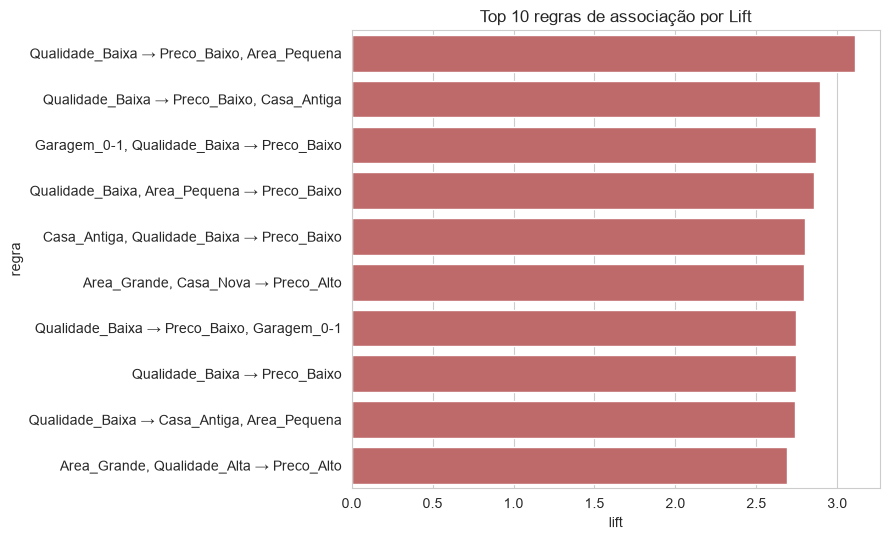

In [80]:
top_rules = rules_df.head(10).copy()
top_rules['regra'] = top_rules['antecedente'] + ' → ' + top_rules['consequente']
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=top_rules, x='lift', y='regra', ax=ax, color='indianred')
ax.set_title('Top 10 regras de associação por Lift')
plt.tight_layout()
plt.show()

## 7b. Aprendizagem Não Supervisionada — Detecção de Outliers (Local Outlier Factor)

44 outliers detectados pelo LOF (3.0% do dataset)


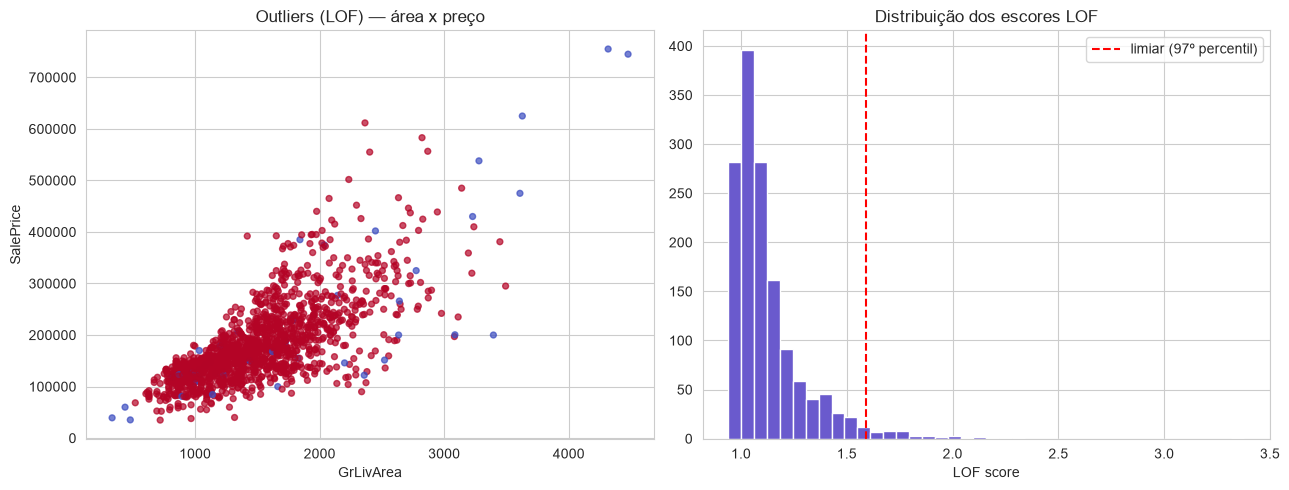


Exemplos de casas identificadas como outliers:
     OverallQual  GrLivArea  TotalSF  TotalBath  GarageCars  YearBuilt  \
53             9       1842   3684.0        2.5         3.0       1981   
89             4        990   1980.0        2.0         0.0       1994   
99             4       1225   2175.0        2.5         0.0       1959   
148            7       1080   2160.0        2.0         0.0       2004   
185           10       3608   4143.0        2.5         3.0       1892   
249            6       2144   3588.0        2.5         2.0       1958   
313            7       2036   4172.0        4.0         2.0       1965   
323            3       1163   2325.0        2.0         1.0       1955   

     LotArea  SalePrice  
53     50271     385000  
89      8070     123600  
99      9320     128950  
148     7500     141000  
185    22950     475000  
249   159000     277000  
313   215245     375000  
323     5820     126175  


In [81]:
lof_feats = ['OverallQual', 'GrLivArea', 'TotalSF', 'TotalBath', 'GarageCars',
             'YearBuilt', 'LotArea']
X_lof = df.iloc[:n_train][lof_feats].reset_index(drop=True).copy()
X_lof['LotArea'] = np.log1p(X_lof['LotArea'])
X_lof['GrLivArea'] = np.log1p(X_lof['GrLivArea'])
X_lof_sc = StandardScaler().fit_transform(X_lof)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
outlier_pred = lof.fit_predict(X_lof_sc)  # -1 = outlier, 1 = normal
lof_scores = -lof.negative_outlier_factor_

n_outliers = (outlier_pred == -1).sum()
print(f'{n_outliers} outliers detectados pelo LOF ({n_outliers/len(X_lof):.1%} do dataset)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(df.iloc[:n_train]['GrLivArea'].values, y_original.values,
                      c=outlier_pred, cmap='coolwarm', alpha=0.7, s=18)
axes[0].set_xlabel('GrLivArea'); axes[0].set_ylabel('SalePrice')
axes[0].set_title('Outliers (LOF) — área x preço')

axes[1].hist(lof_scores, bins=40, color='slateblue')
axes[1].axvline(np.percentile(lof_scores, 97), color='red', linestyle='--', label='limiar (97º percentil)')
axes[1].set_xlabel('LOF score'); axes[1].set_title('Distribuição dos escores LOF')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\nExemplos de casas identificadas como outliers:')
print(df.iloc[:n_train][lof_feats].reset_index(drop=True)[outlier_pred == -1]
      .assign(SalePrice=y_original.values[outlier_pred == -1]).head(8))

## 8. Comparação de Métricas e Conclusão

In [82]:
print('=== REGRESSÃO (prever o valor de SalePrice) ===')
display_reg = pd.DataFrame(reg_results).set_index('modelo').round(2)
print(display_reg)

print('\n=== CLASSIFICAÇÃO (prever faixa Alta/Baixa de preço) ===')
display_clf = pd.DataFrame(clf_results).set_index('modelo').round(3)
print(display_clf)

print('\n=== NÃO SUPERVISIONADO ===')
print(f'K-Means: {K_CHOSEN} clusters | médias de SalePrice variam de '
      f"R$ {cluster_profile.groupby('Cluster')['SalePrice'].mean().min():,.0f} a "
      f"R$ {cluster_profile.groupby('Cluster')['SalePrice'].mean().max():,.0f}")
print(f'PCA: {n_comp_90} componentes explicam 90% da variância '
      f'(2 componentes explicam apenas {pca2.explained_variance_ratio_.sum():.1%})')
print(f'Apriori: {len(frequent_itemsets)} itemsets frequentes, {len(rules_df)} regras com confiança >= 60%')
print(f'LOF: {n_outliers} outliers identificados ({n_outliers/len(X_lof):.1%})')

=== REGRESSÃO (prever o valor de SalePrice) ===
                        RMSE       MAE    R2
modelo                                      
Regressão Linear    22817.50  15474.62  0.91
Random Forest Reg.  23519.88  16413.27  0.90

=== CLASSIFICAÇÃO (prever faixa Alta/Baixa de preço) ===
                     Accuracy  Precision  Recall     F1    AUC
modelo                                                        
Regressão Logística     0.901      0.903   0.897  0.900  0.971
Random Forest Clf.      0.911      0.941   0.877  0.908  0.982

=== NÃO SUPERVISIONADO ===
K-Means: 4 clusters | médias de SalePrice variam de R$ 121,014 a R$ 323,243
PCA: 119 componentes explicam 90% da variância (2 componentes explicam apenas 11.3%)
Apriori: 145 itemsets frequentes, 170 regras com confiança >= 60%
LOF: 44 outliers identificados (3.0%)


### Conclusões

- **Regressão:** a Regressão Linear obteve desempenho levemente superior ao Random
  Forest neste conjunto (após o tratamento cuidadoso de outliers e a transformação
  logarítmica das variáveis assimétricas), com R² acima de 0.90 — ou seja, o modelo
  explica mais de 90% da variância do preço de venda.
- **Classificação:** ambos os modelos (Regressão Logística e Random Forest) distinguem
  muito bem casas "caras" de "baratas" (AUC > 0.97), confirmando que as variáveis de
  qualidade e área são fortemente discriminativas.
- **Clusterização:** o K-Means revelou grupos de imóveis claramente diferenciados por
  qualidade, tamanho e, consequentemente, faixa de preço — útil para segmentação de mercado.
- **PCA:** a forte dimensionalidade do problema (muitas variáveis categóricas após o
  one-hot encoding) faz com que poucas componentes não sejam suficientes para resumir
  bem os dados; ainda assim, a projeção 2D mostra separação visual entre clusters e níveis
  de preço.
- **Apriori:** casas de baixa qualidade tendem fortemente a ter preço baixo (confiança
  até ~95%), enquanto casas novas e grandes apresentam forte associação com preço alto —
  resultados coerentes com a intuição de mercado imobiliário.
- **LOF:** poucos imóveis (3%) se destacam como atípicos, geralmente por combinações raras
  de área, lote ou idade em relação ao seu preço — candidatos a revisão manual antes de
  qualquer modelagem em produção.

## 9. Storytelling

### Perguntas principais

- Quais as características que realmente pesam no preço de uma casa?
- O modelo consegue prever preço de venda com boa precisão ou apenas capturar padrões óbvios?
- Existem grupos de casas com perfis parecidos?
- Quais imóveis fogem do padrão e deveriam ser analisados mais cuidadosamente?

### Pontos importantes

- O preço não depende de uma única variável. Ele combina qualidade geral, área, garagem, idade e padrão de acabamento.
- As variáveis mais fortes foram `OverallQual`, `GrLivArea`, garagem, área do porão, banheiros e features criadas como `TotalSF` e `TotalBath`.
- A transformação logarítmica ajudou porque `SalePrice` é assimétrico e possui poucos imóveis muito caros.

### Pontos para destacar nos resultados

- **Regressão:** R² próximo de 0.91 mostra que o modelo explica grande parte da variação do preço.
- **Classificação:** AUC próxima de 0.98 indica ótima separação entre casas de preço alto e baixo.
- **K-Means:** os 4 clusters formam perfis interpretáveis, com médias de preço indo de cerca de R$ 121 mil a R$ 323 mil.
- **Apriori:** baixa qualidade aparece fortemente associada a preço baixo; casas novas e grandes aparecem associadas a preço alto.
- **LOF:** 44 imóveis foram marcados como outliers, cerca de 3% da base.

### Pontos a serem observados

- A remoção dos dois outliers extremos foi feita porque eram casas muito grandes com preço muito abaixo do padrão visual.
- O Random Forest não ganhou da Regressão Linear na regressão, mas teve ótimo desempenho na classificação.
- As técnicas não supervisionadas não competem diretamente com os modelos supervisionados. Elas ajudam a interpretar segmentos, associações e pontos "fora da curva" ou fora do padrão mesmo.


### Observações finais e fechamento

- Para o objetivo de previsão do preço das casas, os modelos supervisionados foram os mais adequados, porque usaram o `SalePrice` como variável-alvo e conseguiram medir desempenho com métricas objetivas como o R².
- A regressão respondeu melhor à pergunta central de negócio: estimar o valor de venda. A classificação também funcionou, mas simplificou o problema ao transformar preço em apenas duas faixas, nesse caso, alto ou baixo.
- As técnicas não supervisionadas não foram, de certa forma, piores. K-Means, PCA, Apriori e LOF ajudaram a interpretar padrões, segmentar casas semelhantes, encontrar associações e identificar imóveis fora do padrão.
- O principal aprendizado é que os dois tipos de abordagem se complementam: os modelos supervisionados preveem, enquanto os não supervisionados ajudam a explicar e validar os padrões encontrados.
- Entendemos também que a qualidade da preparação dos dados é tão importante quanto a escolha do algoritmo.